# 02 - EDA: đặc trưng tử vong Việt Nam

**Hình cần tạo (chương EDA của luận văn):**
- log m(x,t) theo tuổi ở các năm mốc (1960, 1980, 2000, 2020)
- Heatmap Lexis (tuổi × năm) - quan sát hiệu ứng thế hệ
- Tốc độ cải thiện tử vong theo tuổi
- Tuổi thọ kỳ vọng e0, e60 theo thời gian, so sánh nam/nữ
- So sánh với 1-2 nước châu Á (Nhật, Hàn) để làm nổi bật đặc trưng VN

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import pandas as pd
from src.config import DATA_PROCESSED, load_params

cfg = load_params()
y0, y1 = cfg["data"]["years"]["start"], cfg["data"]["years"]["end"]


def load_mx(sex: str) -> pd.DataFrame:
    mx = pd.read_csv(DATA_PROCESSED / f"mx_{sex}.csv", index_col=0)
    mx.columns = mx.columns.astype(int)
    return mx


mx_total = load_mx("total")
mx_male = load_mx("male")
mx_female = load_mx("female")
mx_total.shape

(101, 69)

## log m(x,t) theo tuổi ở các năm mốc

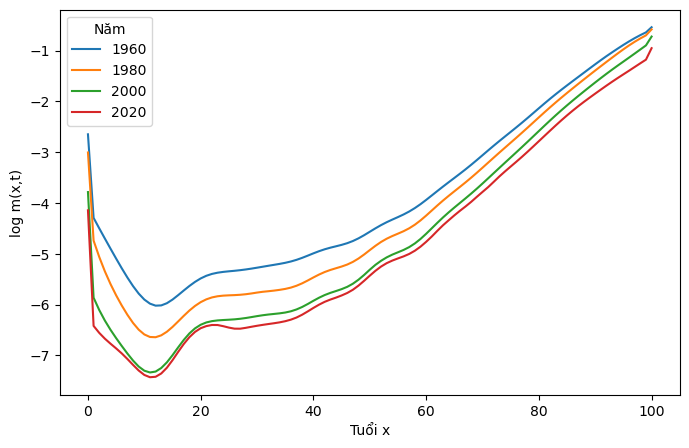

In [3]:
from src.visualization.plots import plot_log_mx_by_age

plot_log_mx_by_age(mx_total, years=[1960, 1980, 2000, 2020], name='log_mx_total_by_age')

## So sánh log m(x,t) theo tuổi giữa nam và nữ

In [ ]:
from src.visualization.plots import plot_mx_sex_comparison

plot_mx_sex_comparison(mx_male, mx_female, years=[1960, 1980, 2000, 2020])

ratio = mx_male[y1] / mx_female[y1]
print(f"Tỷ số mx Nam/Nữ năm {y1}: trung bình {ratio.mean():.2f}, "
      f"cao nhất tại tuổi {ratio.idxmax()} ({ratio.max():.2f} lần), "
      f"thấp nhất tại tuổi {ratio.idxmin()} ({ratio.min():.2f} lần)")

**Nhận xét (năm 2023, dựa trên số liệu tính được ở trên):**

- **Tử vong nam luôn cao hơn nữ ở hầu hết các tuổi** — tỷ số `mx nam/nữ` trung bình
  ≈ 2.36 lần trên toàn bộ dải tuổi, tức đường log m(x,t) của nam gần như luôn nằm
  trên đường của nữ.
- **"Bướu tai nạn" (accident hump) ở nam giới tuổi 15-30**: khoảng cách nam-nữ đạt
  đỉnh quanh tuổi 20 (mx nam gấp **~3.65 lần** mx nữ), rồi giảm dần sau tuổi 30.
  Đây là mô thức tử vong đặc trưng toàn cầu do tử vong ngoại sinh (tai nạn giao
  thông, bạo lực) ở nam thanh niên vượt trội hẳn so với nữ cùng tuổi — ở Việt Nam
  hiệu ứng này có thể càng rõ do tỷ lệ dùng xe máy cao.
- **Khoảng cách thu hẹp dần ở tuổi già**: tỷ số giảm đều từ ~2.1 lần ở tuổi 70
  xuống ~1.4 lần ở tuổi 100 — tử vong tuổi già chủ yếu do nguyên nhân sinh học/bệnh
  lý thoái hoá, ít chịu ảnh hưởng của các yếu tố hành vi phân hoá theo giới như ở
  tuổi trẻ.
- **Ngoại lệ ở tuổi 1**: đây là tuổi duy nhất tỷ số < 1 (mx nữ nhỉnh hơn nam,
  ~0.88 lần) — trái ngược với tuổi 0 (mx nam cao hơn nữ ~1.45 lần, đúng mô thức
  tử vong sơ sinh nam cao hơn nữ đã biết trong y văn). Cần kiểm tra thêm liệu đây
  là biến động thật hay nhiễu/artefact từ việc UN làm trơn (smoothing) dữ liệu Việt
  Nam khi ước lượng bảng sống.
- **Khoảng cách nam-nữ đã doãng ra theo thời gian**: tỷ số trung bình tăng từ
  ~1.36 lần (1960) lên ~2.51 lần (2020) trước khi giảm nhẹ còn ~2.36 lần (2023) —
  gợi ý tử vong nữ giới cải thiện nhanh hơn nam giới trong giai đoạn phát triển
  kinh tế-y tế của Việt Nam, một điểm đáng phân tích sâu hơn ở phần tốc độ cải
  thiện tử vong theo giới (mở rộng từ mục "Tốc độ cải thiện tử vong theo tuổi" ở
  trên, hiện đang tính chung cho `mx_total`).

### Bảng chi tiết và biểu đồ tỷ số m(x,t) Nam/Nữ theo tuổi

In [ ]:
milestone_years = [1960, 1980, 2000, 2020]

ratio_detail = pd.DataFrame({year: mx_male[year] / mx_female[year] for year in milestone_years}).round(3)
ratio_detail.columns.name = "year"
ratio_detail

In [ ]:
from src.visualization.plots import plot_mx_ratio_by_age

plot_mx_ratio_by_age(mx_male, mx_female, years=milestone_years)

## Heatmap Lexis (tuổi × năm)

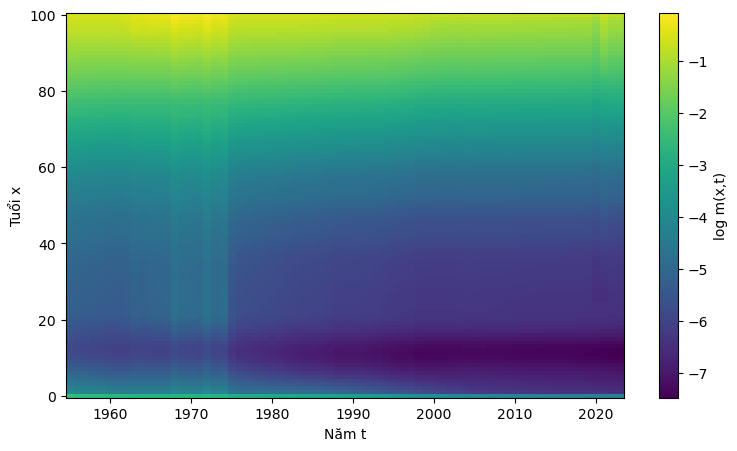

In [4]:
from src.visualization.plots import plot_lexis_heatmap

plot_lexis_heatmap(mx_total)

## Tốc độ cải thiện tử vong theo tuổi

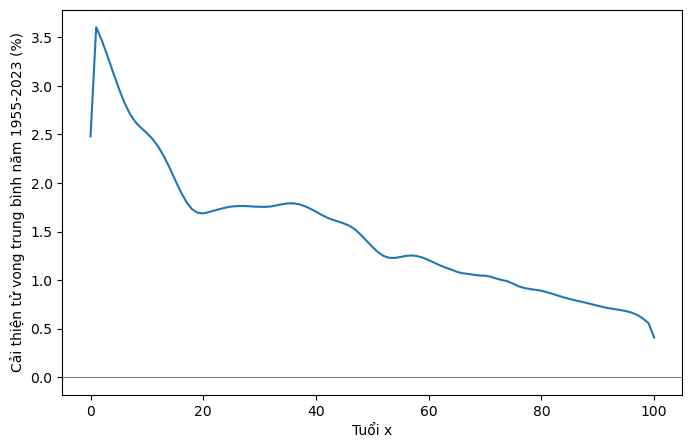

In [5]:
from src.visualization.plots import plot_mortality_improvement_by_age

plot_mortality_improvement_by_age(mx_total, y0, y1)

## Tuổi thọ kỳ vọng e0, e60 theo thời gian, so sánh nam/nữ

`e(x,t)` dựng từ bảng sống suy ra từ `m(x,t)`, giả định lực chết không đổi
trong mỗi khoảng tuổi (xem `src/data/life_table.py`).

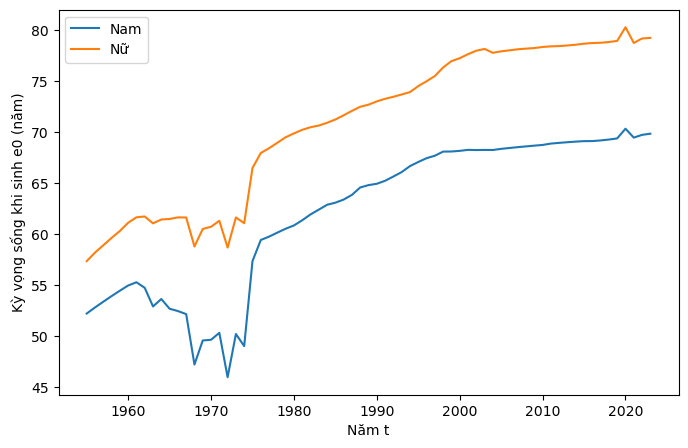

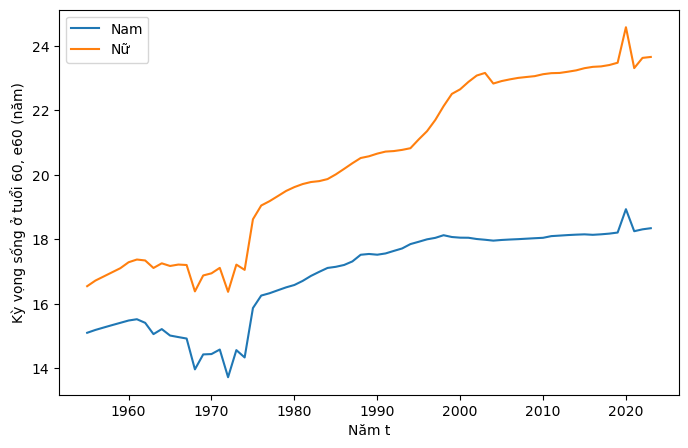

In [6]:
from src.data.life_table import life_expectancy_series
from src.visualization.plots import plot_life_expectancy_trend

e0 = {"Nam": life_expectancy_series(mx_male, age=0), "Nữ": life_expectancy_series(mx_female, age=0)}
e60 = {"Nam": life_expectancy_series(mx_male, age=60), "Nữ": life_expectancy_series(mx_female, age=60)}

plot_life_expectancy_trend(e0, ylabel="Kỳ vọng sống khi sinh e0 (năm)", name="e0_trend_by_sex")
plot_life_expectancy_trend(e60, ylabel="Kỳ vọng sống ở tuổi 60, e60 (năm)", name="e60_trend_by_sex")

## So sánh với Nhật Bản, Hàn Quốc

File UN WPP đã tải chứa toàn bộ các quốc gia, không chỉ Việt Nam - lọc lại
theo mã ISO3 khác (`JPN`, `KOR`) mà không cần tải thêm file.

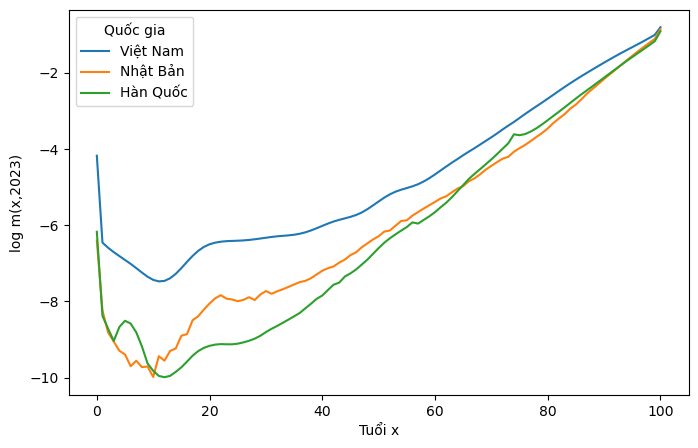

In [7]:
from src.config import DATA_RAW
from src.data.make_dataset import WPP_FILES, build_matrices
from src.data.read_raw import read_wpp_single_age_life_table
from src.visualization.plots import plot_mx_country_comparison

path_total = DATA_RAW / WPP_FILES["total"]

mx_by_country = {"Việt Nam": mx_total}
for label, iso3 in [("Nhật Bản", "JPN"), ("Hàn Quốc", "KOR")]:
    df_c = read_wpp_single_age_life_table(path_total, iso3=iso3)
    _, _, mx_c = build_matrices(df_c, y0, y1)
    mx_by_country[label] = mx_c

plot_mx_country_comparison(mx_by_country, year=y1)